In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing packages for the SVM.

In [40]:
#| echo: true
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

Creating a synthetic classification dataset which is not linearly separable and normalizing the features.

In [42]:
#| echo: true
X, y = make_circles(n_samples=150, factor=0.5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Creating one linear model and one model with RBF.

In [44]:
#| echo: true
svm_linear = SVC(kernel='linear', C=1.0).fit(X_train_scaled, y_train)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='auto').fit(X_train_scaled, y_train)

Plotting the decision boundaries of each model.

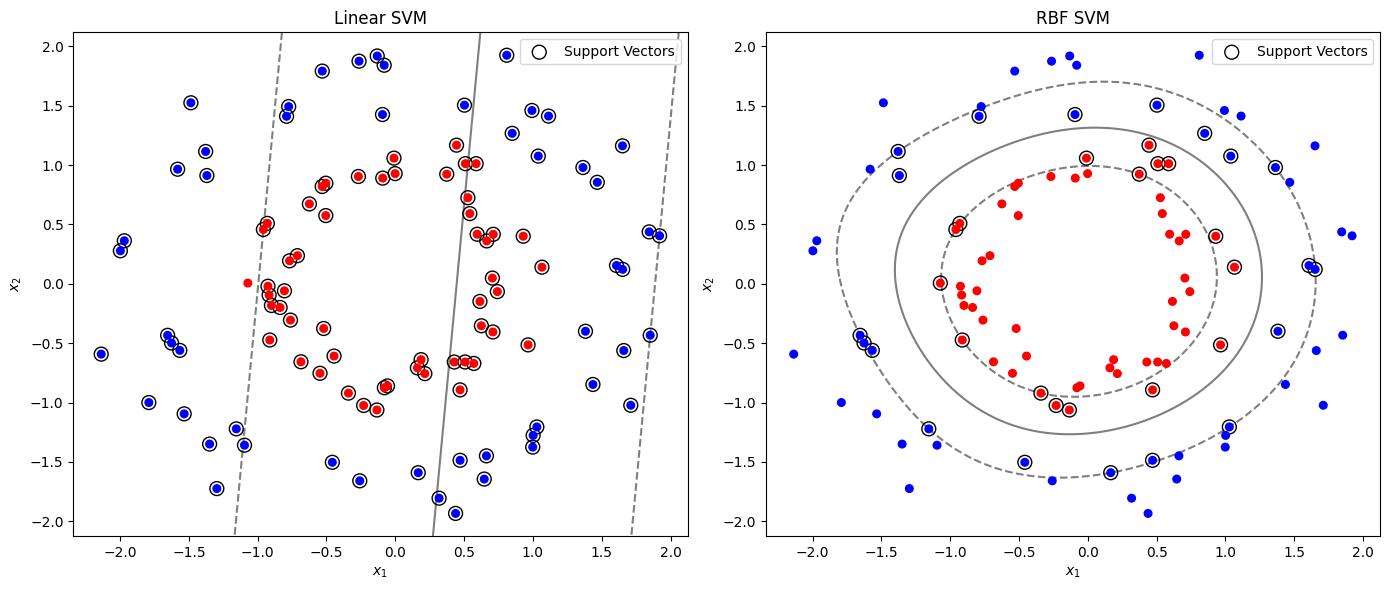

In [47]:
#| echo: true
def plot_svm_boundary(model, X, y, ax, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=30, zorder=3)

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_svm_boundary(svm_linear, X_train_scaled, y_train, axes[0], "Linear SVM")
plot_svm_boundary(svm_rbf, X_train_scaled, y_train, axes[1], "RBF SVM")

plt.tight_layout()
plt.show()

Printing the classifications reports of each model.

In [48]:
#| echo: true
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

rep_linear = classification_report(y_test, y_pred_linear)
rep_rbf = classification_report(y_test, y_pred_rbf)

print("Linear")
print(rep_linear)
print(60*"=")
print("RBF")
print(rep_rbf)
print(60*"=")

Linear
              precision    recall  f1-score   support

           0       0.50      0.35      0.41        23
           1       0.48      0.64      0.55        22

    accuracy                           0.49        45
   macro avg       0.49      0.49      0.48        45
weighted avg       0.49      0.49      0.48        45

RBF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        22

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



As it was shown in the plot, the linear SVM was not able to separate the classes, while the RBF SVM was able to separate the observations.